<a href="https://colab.research.google.com/github/lucaslopesassad-bit/UENF_LucasAssad/blob/main/trabalho_final_parte_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q cdsapi xarray netCDF4 cartopy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.0 MB/s eta 0:00:00


In [ ]:

import cdsapi
import xarray as xr
import netCDF4
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

In [ ]:

from getpass import getpass
import os

# Cole seu Personal Access Token do Copernicus CDS quando solicitado (nao fica visivel na tela)
cds_token = getpass('Cole aqui o seu Personal Access Token do Copernicus CDS: ')

cdsapirc_content = f"url: https://cds.climate.copernicus.eu/api\nkey: {cds_token}\n"

cdsapirc_path = os.path.expanduser('~/.cdsapirc')
with open(cdsapirc_path, 'w') as f:
    f.write(cdsapirc_content)

print(f'Arquivo {cdsapirc_path} criado com sucesso!')

Cole aqui o seu Personal Access Token do Copernicus CDS: ··········
Arquivo /root/.cdsapirc criado com sucesso!


In [ ]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
'reanalysis-era5-single-levels',
{
'product_type': 'reanalysis',
'variable': [
'2m_temperature',
'2m_dewpoint_temperature',
'total_precipitation',
'10m_u_component_of_wind',
'10m_v_component_of_wind',
],
'year': '2024',
'month': [
'01', '02', '03', '04', '05', '06',
'07', '08', '09', '10', '11', '12',
],
'day': [
'01', '02', '03', '04', '05', '06', '07', '08', '09', '10',
'11', '12', '13', '14', '15', '16', '17', '18', '19', '20',
'21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31',
],
'time': '15:00',
'area': [3, -59, -10, -46],
'format': 'netcdf',
},
'era5_para_2024.nc'
)

2026-07-05 23:30:45,563 INFO Request ID is 281888f1-5791-4067-a7d2-c534e0c09d1b
INFO:ecmwf.datastores.legacy_client:Request ID is 281888f1-5791-4067-a7d2-c534e0c09d1b
2026-07-05 23:30:45,715 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-05 23:31:07,405 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-05 23:35:05,858 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


f2c698a1941740a41e21dc2393e8095f.zip:   0%|          | 0.00/8.44M [00:00<?, ?B/s]

'era5_para_2024.nc'

In [ ]:
ds = xr.open_dataset('era5_para_2024.nc')
print(ds)

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [ ]:
!file era5_para_2024.nc
!ls -la era5_para_2024.nc

era5_para_2024.nc: Zip archive data, at least v2.0 to extract, compression method=deflate
-rw-r--r-- 1 root root 8846583 Jul  5 23:35 era5_para_2024.nc


In [ ]:
import zipfile, os

os.makedirs('era5_para_2024_extracted', exist_ok=True)
with zipfile.ZipFile('era5_para_2024.nc', 'r') as z:
    z.extractall('era5_para_2024_extracted')
print(os.listdir('era5_para_2024_extracted'))

['data_stream-oper_stepType-accum.nc', 'data_stream-oper_stepType-instant.nc']


In [ ]:
nt, ds_accum])

ds['t2m_c'] = ds['t2m'] - 273.15
ds['d2m_c'] = ds['d2m'] - 273.15

ds['wind_speed'] = np.sqrt(ds['u10']**2 + ds['v10']**2)

a = 17.625
b = 243.04
ds['rh'] = 100 * (np.exp((a * ds['d2m_c']) / (b + ds['d2m_c'])) / np.exp((a * ds['t2m_c']) / (b + ds['t2m_c'])))

month = ds['valid_time'].dt.month
season = xr.where(month.isin([12, 1, 2]), 'Verao', xr.where(month.isin([3, 4, 5]), 'Outono', xr.where(month.isin([6, 7, 8]), 'Inverno', 'Primavera')))
ds = ds.assign_coords(season=('valid_time', season.data))

variaveis = ['t2m_c', 'd2m_c', 'tp', 'wind_speed', 'rh']
seasonal_mean = ds[variaveis].groupby('season').mean(dim='valid_time')

seasonal_mean_domain = seasonal_mean.mean(dim=['latitude', 'longitude'])
df_sazonal = seasonal_mean_domain.to_dataframe()[variaveis]
print(df_sazonal)

SyntaxError: unmatched ']' (2998261350.py, line 1)

In [ ]:
ds_instant = xr.open_dataset('era5_para_2024_extracted/data_stream-oper_stepType-instant.nc')
ds_accum = xr.open_dataset('era5_para_2024_extracted/data_stream-oper_stepType-accum.nc')
print(ds_instant)
print('----')
print(ds_accum)

<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 366, latitude: 53, longitude: 53)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
  * latitude    (latitude) float64 424B 3.0 2.75 2.5 2.25 ... -9.5 -9.75 -10.0
  * longitude   (longitude) float64 424B -59.0 -58.75 -58.5 ... -46.25 -46.0
    number      int64 8B ...
    expver      (valid_time) <U4 6kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
    d2m         (valid_time, latitude, longitude) float32 4MB ...
    u10         (valid_time, latitude, longitude) float32 4MB ...
    v10         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07

In [ ]:
ds = xr.merge([ds_instant, ds_accum])

ds['t2m_c'] = ds['t2m'] - 273.15
ds['d2m_c'] = ds['d2m'] - 273.15

ds['wind_speed'] = np.sqrt(ds['u10']**2 + ds['v10']**2)

a = 17.625
b = 243.04
ds['rh'] = 100 * (np.exp((a * ds['d2m_c']) / (b + ds['d2m_c'])) / np.exp((a * ds['t2m_c']) / (b + ds['t2m_c'])))

month = ds['valid_time'].dt.month
season = xr.where(month.isin([12, 1, 2]), 'Verao', xr.where(month.isin([3, 4, 5]), 'Outono', xr.where(month.isin([6, 7, 8]), 'Inverno', 'Primavera')))
ds = ds.assign_coords(season=('valid_time', season.data))

variaveis = ['t2m_c', 'd2m_c', 'tp', 'wind_speed', 'rh']
seasonal_mean = ds[variaveis].groupby('season').mean(dim='valid_time')

seasonal_mean_domain = seasonal_mean.mean(dim=['latitude', 'longitude'])
df_sazonal = seasonal_mean_domain.to_dataframe()[variaveis]
print(df_sazonal)

/tmp/ipykernel_946/2048168521.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_instant, ds_accum])
/tmp/ipykernel_946/2048168521.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_instant, ds_accum])


               t2m_c      d2m_c        tp  wind_speed         rh
season                                                          
Inverno    31.527023  20.093451  0.000059    3.097662  53.208027
Outono     29.478067  23.696228  0.000481    2.323541  72.213486
Primavera  32.261631  21.271244  0.000075    2.791472  54.198524
Verao      29.233675  23.173569  0.000384    2.678828  70.890877


In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

os.makedirs('mapas_era5', exist_ok=True)

variaveis_info = {'t2m_c': ('Temperatura (C)', 'coolwarm'), 'rh': ('Umidade Relativa (%)', 'YlGnBu'), 'wind_speed': ('Intensidade do Vento (m/s)', 'viridis'), 'tp': ('Precipitacao (m)', 'Blues')}
estacoes = ['Verao', 'Outono', 'Inverno', 'Primavera']
states_provinces = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='50m', facecolor='none')
combinacoes = [(var, estacao) for var in variaveis_info for estacao in estacoes]

def gerar_mapa(var, estacao):
    label, cmap = variaveis_info[var]
    dado = seasonal_mean[var].sel(season=estacao)
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-59, -46, -10, 3], crs=ccrs.PlateCarree())
    cs = ax.contourf(dado['longitude'], dado['latitude'], dado.values, levels=15, cmap=cmap, transform=ccrs.PlateCarree())
    ax.coastlines(resolution='50m')
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    cbar = plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
    cbar.set_label(label)
    ax.plot(-48.77, -1.98, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree())
    ax.text(-48.60, -1.98, 'Igarape-Miri', fontsize=8, color='black', weight='bold', transform=ccrs.PlateCarree())
    ax.plot(-49.49, -2.24, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree())
    ax.text(-49.32, -2.24, 'Cameta', fontsize=8, color='black', weight='bold', transform=ccrs.PlateCarree())
    ax.plot(-48.88, -1.72, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree())
    ax.text(-48.71, -1.72, 'Abaetetuba', fontsize=8, color='black', weight='bold', transform=ccrs.PlateCarree())
    ax.set_title(f'{label} - {estacao} (Para, 2024)')
    nome_arquivo = f'mapas_era5/{var}_{estacao}.png'
    plt.savefig(nome_arquivo, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return nome_arquivo
arquivos_png = [gerar_mapa(var, estacao) for var, estacao in combinacoes]
print(f'{len(arquivos_png)} mapas gerados:')
for f in arquivos_png:
    print(f)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


16 mapas gerados:
mapas_era5/t2m_c_Verao.png
mapas_era5/t2m_c_Outono.png
mapas_era5/t2m_c_Inverno.png
mapas_era5/t2m_c_Primavera.png
mapas_era5/rh_Verao.png
mapas_era5/rh_Outono.png
mapas_era5/rh_Inverno.png
mapas_era5/rh_Primavera.png
mapas_era5/wind_speed_Verao.png
mapas_era5/wind_speed_Outono.png
mapas_era5/wind_speed_Inverno.png
mapas_era5/wind_speed_Primavera.png
mapas_era5/tp_Verao.png
mapas_era5/tp_Outono.png
mapas_era5/tp_Inverno.png
mapas_era5/tp_Primavera.png


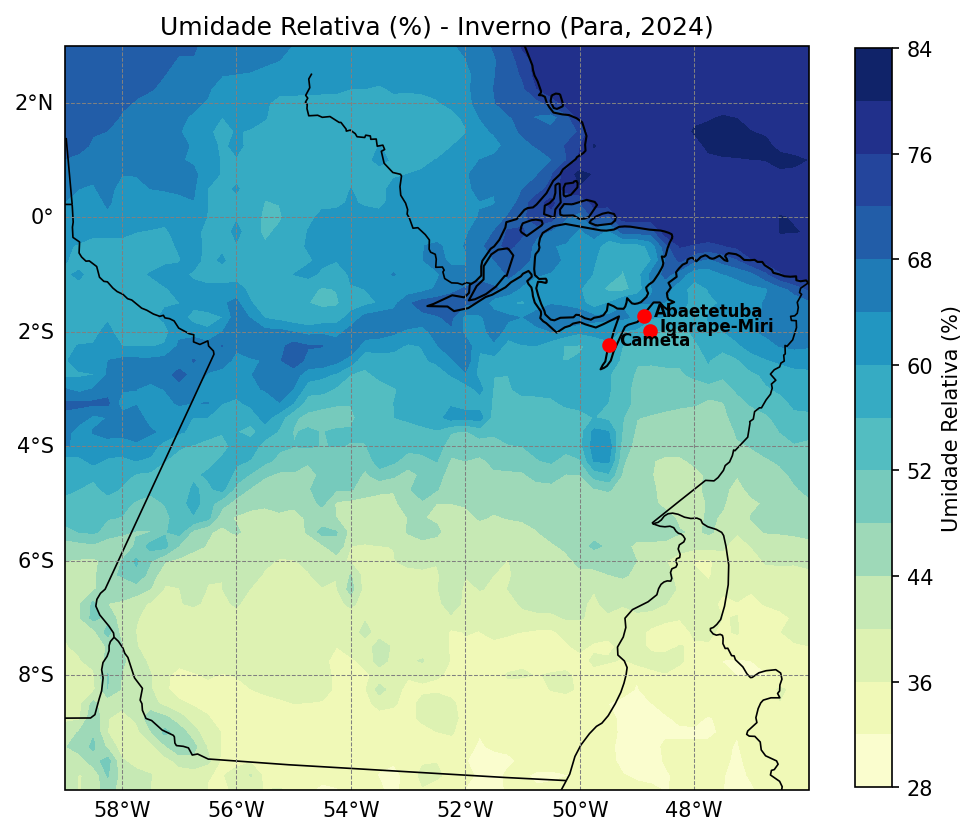

In [ ]:
from IPython.display import Image, display
display(Image('mapas_era5/rh_Inverno.png'))

In [ ]:
import shutil

shutil.make_archive('mapas_era5', 'zip', 'mapas_era5')
print('Arquivo compactado criado: mapas_era5.zip')

Arquivo compactado criado: mapas_era5.zip


In [ ]:
from google.colab import files

files.download('mapas_era5.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>